# Atelier Préparation de Données Textuelles

- Contexte 

Une entreprise souhaite développer un système capable de classer automatiquement des avis 
clients afin d'identifier leur sentiment. 

Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction, 
réseaux sociaux et service client. 

Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe, 
majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères, 
textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes. 
Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent 
donc construire un pipeline complet de préparation des données textuelles.

- Structure du projet 

atelier_prepa_donnees_textuelles/ 

│ 
├──         notebooks/ 

│   
└──_____________atelier_prepa_donnees_textuelles.ipynb 

│  
└──          __data/ 

├── ___________smart_reviews_raw.csv 

├── ____________smart_reviews_cleaned.csv 

└── _____________tfidf_matrix.npz 

# Partie 1 – Exploration du corpus

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1) Charger les données CSV ; 

In [153]:
df = pd.read_csv("../data/smart_reviews_raw.csv")

2) Combien d'avis contient le dataset ?

In [154]:
nb_avis = len(df)
print("Nombre d'avis:", nb_avis)

Nombre d'avis: 1200


3) Combien de colonnes possède-t-il ? 

In [155]:
nb_colonnes = df.shape[1]
print("Nombre de colonnes:", nb_colonnes)

Nombre de colonnes: 8


4) Quel est le type de chaque colonne ? 

In [156]:
df.dtypes

id_avis      object
date         object
source       object
produit      object
texte        object
sentiment    object
note          int64
langue       object
dtype: object

5) Existe-t-il des valeurs manquantes ? 

In [157]:
df.isnull().sum()

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

6) Identifier quelques types de texte en affichant par exemple : 

-  texte normal ;

In [158]:
df["type_texte"] = "texte normal"

df.loc[df["texte"].isna(), "type_texte"] = "texte vide"
df.loc[df["texte"].astype(str).str.strip() == "", "type_texte"] = "texte vide"

df[["texte", "type_texte"]]

,texte,type_texte
0,"Très bonne expérience, simple et efficace.",texte normal
1,Très satisfait de mon achat 👍 #avis,texte normal
2,"Produit parfait, rien à signaler.",texte normal
3,"Produit excellent, je suis très satisfait. !!!",texte normal
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,texte normal
...,...,...
1195,La batterie se décharge beaucoup trop vite.,texte normal
1196,"Très bonne expérience, simple et efficace. !!!",texte normal
1197,Produit correct pour son prix. !!!,texte normal
1198,Excellent rapport qualité-prix. #avis,texte normal


- texte vide

In [159]:
texte = df["texte"].fillna("")
df.loc[
    texte.str.strip() == "",
    ["texte"]
]

,texte
46,NaN
108,NaN
310,NaN
640,NaN
781,NaN
951,


- Texte contenant une URL

In [160]:
df.loc[
    texte.str.contains(
        r"https?://|www\.",
        case=False,
        regex=True
    ),
    ["texte"]
]

,texte
16,"Produit parfait, rien à signaler. https://exam..."
30,"Très bonne expérience, simple et efficace. htt..."
31,"Je viens de recevoir le produit, à voir dans l..."
34,"Produit parfait, rien à signaler. https://exam..."
35,"Très bon produit, la qualité est au rendez-vou..."
...,...
1169,"Très bonne expérience, simple et efficace. htt..."
1172,La batterie tient vraiment bien et l'écran est...
1185,Excellent rapport qualité-prix. https://exampl...
1191,L'utilisation est assez simple. https://exampl...


In [161]:
### Comptage des texte contenant des URL
texte.str.contains(
    r"https?://|www\.",
    regex=True
).sum()

np.int64(143)

- texte contenant une mention 


In [162]:
df.loc[
    texte.str.contains(
        r"@\w+",
        regex=True
    ),
    ["texte"]
]

,texte
9,@client Livraison rapide et produit conforme à...
32,@client Service client réactif et commande reç...
40,@client La qualité est correcte sans être exce...
44,"@client Je recommande vivement, tout fonctionn..."
45,@client Excellent rapport qualité-prix.
...,...
1151,@client La livraison s'est déroulée normalement.
1155,@client Excellent rapport qualité-prix.
1175,@client Excellent rapport qualité-prix.
1193,"@client Très bonne expérience, simple et effic..."


In [163]:
#### Comptage des mentions
texte.str.contains(
    r"@\w+",
    regex=True
).sum()

np.int64(128)

- texte contenant un hashtag

In [164]:
df.loc[
    texte.str.contains(
        r"#\w+",
        regex=True
    ),
    ["texte"]
]

,texte
1,Très satisfait de mon achat 👍 #avis
12,La batterie tient vraiment bien et l'écran est...
15,Produit correct pour son prix. #avis
38,"Très bonne expérience, simple et efficace. #avis"
69,La batterie tient vraiment bien et l'écran est...
...,...
1163,Le produit correspond globalement à la descrip...
1166,Le service client n'a pas répondu à ma demande...
1179,"Produit parfait, rien à signaler. #avis"
1194,"Très bon produit, la qualité est au rendez-vou..."


In [166]:
texte.str.contains(
        r"#\w+",
        regex=True
    ).sum()

np.int64(127)

- texte contenant des emojis 

In [167]:
df.loc[
    texte.str.contains(
        r"[\U0001F300-\U0001FAFF]",
        regex=True
    ),
    ["texte"]
]

,texte
1,Très satisfait de mon achat 👍 #avis
5,Très satisfait de mon achat 👍 😊
7,Très satisfait de mon achat 👍
10,Très satisfait de mon achat 👍 !!!
19,"Je viens de recevoir le produit, à voir dans l..."
...,...
1176,Le produit correspond globalement à la descrip...
1180,Excellent rapport qualité-prix. 😊
1181,Très satisfait de mon achat 👍 😊
1187,Très satisfait de mon achat 👍


In [168]:
## Comptage des textes avec emojis
texte.str.contains(
        r"[\U0001F300-\U0001FAFF]",
        regex=True
    ).sum()


np.int64(192)

- texte avec beaucoup de ponctuation 

Nous devons d'abord décider ce que signifie « beaucoup ».

Pour notre atelier, nous pouvons considérer qu'un texte possède beaucoup de ponctuation lorsque 30 % ou plus de ses caractères sont des signes de ponctuation.

Commençons par compter les caractères de ponctuation 

In [169]:
nombre_ponctuation = texte.str.count(r"[^\w\s]") ### Comptage des caracteres de ponctuation
longueur_texte = texte.str.len() #### Longueur du texte
df.loc[
    (longueur_texte > 0) &
    ((nombre_ponctuation / longueur_texte) >= 0.30),
    ["texte"]
]


,texte
952,super produit!!!!!!!!!!!!!!!!!!!!!!!!


In [170]:
(
    (longueur_texte > 0) &
    ((nombre_ponctuation / longueur_texte) >= 0.30)
).sum()

np.int64(1)

 - texte en majuscules

In [172]:
## Verifions d'abord qu'il contient au moins une lettre
contient_lettre = texte.str.contains(
    r"[A-Za-zÀ-ÖØ-öø-ÿ]",
    regex=True
)

In [173]:
df.loc[
    contient_lettre &
    (texte == texte.str.upper()),
    ["texte"]
]

,texte
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
17,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
23,"PRODUIT EXCELLENT, JE SUIS TRÈS SATISFAIT."
24,TRÈS SATISFAIT DE MON ACHAT 👍
...,...
1145,"MAUVAISE EXPÉRIENCE, JE NE RECOMMANDE PAS."
1167,LIVRAISON RAPIDE ET PRODUIT CONFORME À MES ATT...
1174,"TRÈS BON PRODUIT, LA QUALITÉ EST AU RENDEZ-VOUS."
1184,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...


In [174]:
## Comptage 
(
    contient_lettre &
    (texte == texte.str.upper())
).sum()

np.int64(146)

- texte avec 
répétition de caractères. 

In [175]:
df.loc[
    texte.str.contains(
        r"(.)\1{2,}",
        regex=True
    ),
    ["texte"]
]

C:\Users\bmd\AppData\Local\Temp\ipykernel_15440\1325051527.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  texte.str.contains(


,texte
3,"Produit excellent, je suis très satisfait. !!!"
10,Très satisfait de mon achat 👍 !!!
14,Qualité décevante pour ce prix. !!!
25,"Produit reçu endommagé, je suis mécontent. !!!"
28,"Produit excellent, je suis trèèès satisfait."
...,...
1183,"Je recommande vivement, tout fonctionne parfai..."
1186,"Très bonne expérience, simple et efficace. !!!"
1190,La batterie tient vraiment bien et l'écran est...
1196,"Très bonne expérience, simple et efficace. !!!"


In [176]:
## comptage 
texte.str.contains(
    r"(.)\1{2,}",
    regex=True
).sum()

C:\Users\bmd\AppData\Local\Temp\ipykernel_15440\604504094.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  texte.str.contains(


np.int64(165)

In [177]:
df["est_vide"] = texte.str.strip() == ""

In [178]:
df["contient_url"] = texte.str.contains(
    r"https?://|www\.",
    case=False,
    regex=True
)

In [179]:
df["contient_mention"] = texte.str.contains(
    r"@\w+",
    regex=True
)

In [180]:
df["contient_hashtag"] = texte.str.contains(
    r"#\w+",
    regex=True
)

In [181]:
df["contient_emoji"] = texte.str.contains(
    r"[\U0001F300-\U0001FAFF]",
    regex=True
)

In [182]:
df["beaucoup_ponctuation"] = (
    (longueur_texte > 0) &
    ((nombre_ponctuation / longueur_texte) >= 0.30)
)

In [183]:
df["est_majuscules"] = (
    contient_lettre &
    (texte == texte.str.upper())
)

In [184]:
df["repetition_caracteres"] = texte.str.contains(
    r"(.)\1{2,}",
    regex=True
)

C:\Users\bmd\AppData\Local\Temp\ipykernel_15440\993799879.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["repetition_caracteres"] = texte.str.contains(


In [185]:
df[
    [
        "texte",
        "est_vide",
        "contient_url",
        "contient_mention",
        "contient_hashtag",
        "contient_emoji",
        "beaucoup_ponctuation",
        "est_majuscules",
        "repetition_caracteres"
    ]
].head(20)

,texte,est_vide,contient_url,contient_mention,contient_hashtag,contient_emoji,beaucoup_ponctuation,est_majuscules,repetition_caracteres
0,"Très bonne expérience, simple et efficace.",False,False,False,False,False,False,False,False
1,Très satisfait de mon achat 👍 #avis,False,False,False,True,True,False,False,False
2,"Produit parfait, rien à signaler.",False,False,False,False,False,False,False,False
3,"Produit excellent, je suis très satisfait. !!!",False,False,False,False,False,False,False,True
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,False,False,False,False,False,False,True,False
5,Très satisfait de mon achat 👍 😊,False,False,False,False,True,False,False,False
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,False,False,False,False,False,False,True,False
7,Très satisfait de mon achat 👍,False,False,False,False,True,False,False,False
8,Le produit correspond globalement à la d...,False,False,False,False,False,False,False,False
9,@client Livraison rapide et produit conforme à...,False,False,True,False,False,False,False,False


7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer : 
longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles. 

- La longueur des textes

In [187]:
df["longueur"] = texte.str.len()
df[["texte", "longueur"]].head(10)

,texte,longueur
0,"Très bonne expérience, simple et efficace.",47
1,Très satisfait de mon achat 👍 #avis,35
2,"Produit parfait, rien à signaler.",37
3,"Produit excellent, je suis très satisfait. !!!",46
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,55
5,Très satisfait de mon achat 👍 😊,31
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,52
7,Très satisfait de mon achat 👍,34
8,Le produit correspond globalement à la d...,57
9,@client Livraison rapide et produit conforme à...,60


- Longueur minimale

In [192]:
df["longueur"].min()


0

- Longueur maximale

In [193]:
df["longueur"].max()

636

- Longueur moyenne

In [194]:
df[["longueur"]].mean()

longueur    48.963333
dtype: float64

- La mediane

In [195]:
df[["longueur"]].median()

longueur    48.0
dtype: float64

- Les quartiles

In [196]:
df[["longueur"]].quantile([0.25, 0.50, 0.75])

,longueur
0.25,37.0
0.50,48.0
0.75,56.0


8) Visualiser la distribution de la longueur des avis puis répondre aux questions 

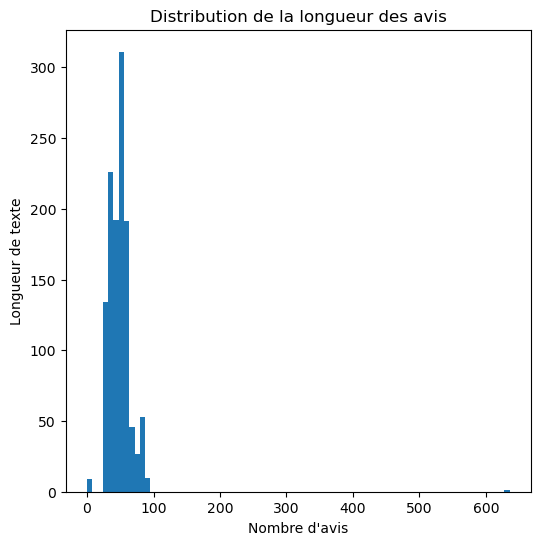

In [197]:
plt.figure(figsize=(6, 6))

plt.hist(df["longueur"], bins=80)

plt.xlabel("Nombre d'avis")
plt.ylabel("Longueur de texte")
plt.title("Distribution de la longueur des avis")

plt.show()

Analyse de l'histogramme:la visualisation de cet histogramme nous montre qu'effectivement il y a des textes anormalement longs et beaucoup de textes tres courts


a) Existe-t-il des textes anormalement longs ? 

In [198]:
Q1 = df["longueur"].quantile(0.25)
Q3 = df["longueur"].quantile(0.75)

IQR = Q3 - Q1

In [199]:
seuil_superieur = Q3 + 1.5 * IQR

In [200]:
df.loc[
    df["longueur"] > seuil_superieur,
    ["texte", "longueur"]
]

,texte,longueur
31,"Je viens de recevoir le produit, à voir dans l...",86
51,"Je viens de recevoir le produit, à voir dans l...",86
110,La batterie tient vraiment bien et l'écran est...,88
123,Service client réactif et commande reçue rapid...,85
145,Livraison rapide et produit conforme à mes att...,85
294,"Je recommande vivement, tout fonctionne parfai...",86
306,"Je viens de recevoir le produit, à voir dans l...",87
313,"Je viens de recevoir le produit, à voir dans l...",87
318,La batterie tient vraiment bien et l'écran est...,88
340,"Je viens de recevoir le produit, à voir dans l...",87


In [201]:
(df["longueur"] > seuil_superieur).sum()

np.int64(41)

Nous avons identifié 41 textes qui dépassaient le seuil fqisqnt d'eux des textes anormalement longs.

b) Existe-t-il beaucoup de textes très courts ? 

In [202]:
##### les textes ayant moins de 20 caracteres sont consideres comme tres courts
df.loc[
    df["longueur"] < 20,
    ["texte", "longueur"]
]

,texte,longueur
46,NaN,0
108,NaN,0
224,OK,2
310,NaN,0
554,Pas bon,7
640,NaN,0
781,NaN,0
889,OK,2
951,,3


In [203]:
(df["longueur"] < 20).sum()  ### Comptage 

np.int64(9)

9) Détecter les textes vides 

In [204]:
df.loc[
    texte.str.strip() == "",
    ["texte"]
]

,texte
46,NaN
108,NaN
310,NaN
640,NaN
781,NaN
951,


10) Détecter les doublons sur le texte 

In [205]:
df["texte"].duplicated().sum()

np.int64(881)

In [206]:
df.loc[
    df["texte"].duplicated(keep=False),
    ["texte"]
].sort_values("texte")

,texte
312,@client Excellent rapport qualité-prix.
419,@client Excellent rapport qualité-prix.
1099,@client Excellent rapport qualité-prix.
45,@client Excellent rapport qualité-prix.
466,@client Excellent rapport qualité-prix.
...,...
46,NaN
108,NaN
310,NaN
640,NaN


11) Les classes sont-elles équilibrées ?

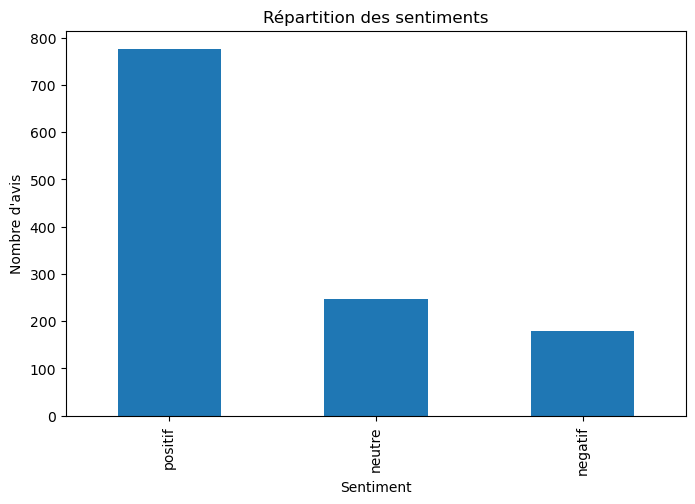

In [207]:
df["sentiment"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Sentiment")
plt.ylabel("Nombre d'avis")
plt.title("Répartition des sentiments")

plt.show()

La distribution des classes est desequilibree.

12) Quelle est la classe majoritaire ?

In [208]:
df["sentiment"].value_counts().idxmax()

'positif'

13) Quelles métriques de classification à envisager d’utiliser ? 

Les classes sont desquilibrees donc nous pouvons utiliser le F1-score, le recall et la precision.

14) Détecter les caractères particuliers : emojis ; URLs ; hashtags ; mentions ; chiffres ; caractères 
spéciaux ; ponctuation répétée ; … 

In [209]:
### Contient des URLs
df["contient_url"] = texte.str.contains(
    r"https?://|www\.",
    case=False,
    regex=True
)

In [211]:
## Contient des Hashtags 
df["contient_url"] = texte.str.contains(
    r"https?://|www\.",
    case=False,
    regex=True
)

In [212]:
## Contient des mentions
df["contient_mention"] = texte.str.contains(
    r"@\w+",
    regex=True
)

In [213]:
## Contient des Emojis
df["contient_emoji"] = texte.str.contains(
    r"[\U0001F300-\U0001FAFF]",
    regex=True
)


In [214]:
## Contient des chiffres
df["contient_chiffre"] = texte.str.contains(
    r"\d",
    regex=True
)

In [215]:
## Contient des caracteres
df["contient_caractere_special"] = texte.str.contains(
    r"[^\w\s]",
    regex=True
)

In [216]:
## Contient des ponctuations repetees
df["contient_ponctuation_repetee"] = texte.str.contains(
    r"([!?.,;:])\1+",
    regex=True
)

C:\Users\bmd\AppData\Local\Temp\ipykernel_15440\149322363.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["contient_ponctuation_repetee"] = texte.str.contains(


In [217]:
## Affichage du resume des caracteristiques
df[
    [
        "texte",
        "contient_url",
        "contient_mention",
        "contient_hashtag",
        "contient_emoji",
        "contient_chiffre",
        "contient_caractere_special",
        "contient_ponctuation_repetee"
    ]
].head(20)

,texte,contient_url,contient_mention,contient_hashtag,contient_emoji,contient_chiffre,contient_caractere_special,contient_ponctuation_repetee
0,"Très bonne expérience, simple et efficace.",False,False,False,False,False,True,False
1,Très satisfait de mon achat 👍 #avis,False,False,True,True,False,True,False
2,"Produit parfait, rien à signaler.",False,False,False,False,False,True,False
3,"Produit excellent, je suis très satisfait. !!!",False,False,False,False,False,True,True
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,False,False,False,False,False,True,False
5,Très satisfait de mon achat 👍 😊,False,False,False,True,False,True,False
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,False,False,False,False,False,True,False
7,Très satisfait de mon achat 👍,False,False,False,True,False,True,False
8,Le produit correspond globalement à la d...,False,False,False,False,False,True,False
9,@client Livraison rapide et produit conforme à...,False,True,False,False,False,True,False


15) Visualiser et commenter nombre d'avis par source 

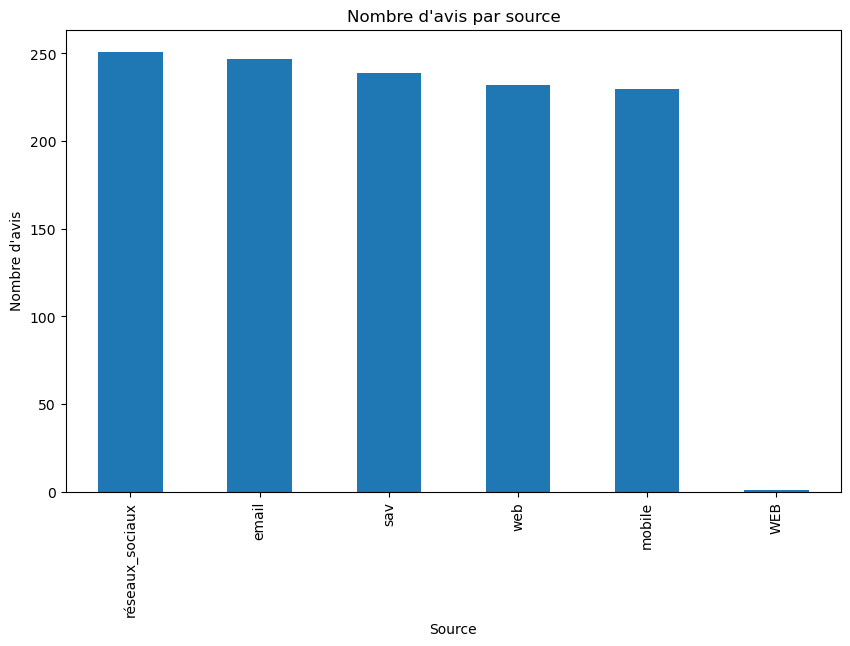

In [218]:
df["source"].value_counts().plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Source")
plt.ylabel("Nombre d'avis")
plt.title("Nombre d'avis par source")

plt.show()

Dans cette distribution les reseaux sociaux comptabilisent les plus garnds nombre d'avis et constitue la source de donnees qui domine fortement le corpus.

Les donnees ne sont pas equitablement reparties car les avis provenant de la source Web 

16) Visualiser et commenter le nombre d'avis par produit 

In [219]:
df["produit"].value_counts()

produit
Écouteurs AirSound     218
Ordinateur NovaBook    217
SmartPhone X           201
SmartWatch Pro         193
Tablette TabPlus       187
SmartPhone Y           184
Name: count, dtype: int64

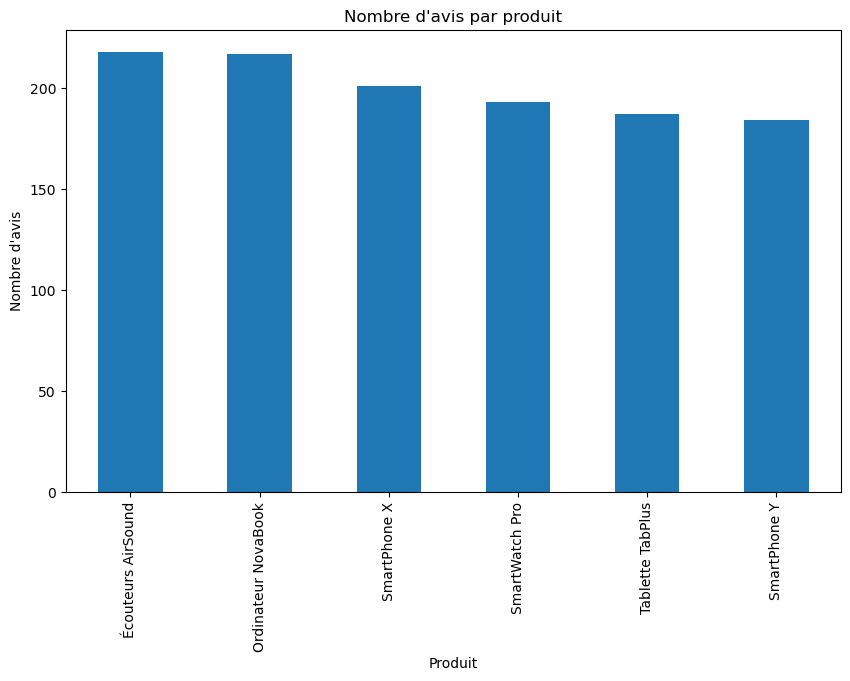

In [220]:
df["produit"].value_counts().plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Produit")
plt.ylabel("Nombre d'avis")
plt.title("Nombre d'avis par produit")

plt.show()

Les ecouteurs Airsound ont recu le plus grands nombre d'avis suivi des ordinateurs Novabook.

# Partie 2 – Nettoyage 

1) Supprimer les lignes contenant des valeurs manquantes de texte

In [221]:
df["texte"].isna().sum()  # Le nombre de valeur manquante

np.int64(5)

In [222]:
df = df.dropna(subset=["texte"])  ## Suppression des valeur manquantes
df["texte"].isna().sum()  

np.int64(0)

2) Supprimer les doublons

In [223]:
df = df.drop_duplicates(subset=["texte"])
df["texte"].duplicated().sum()

np.int64(0)

3) Supprimer les URLs 

In [224]:
df["texte_clean"] = df["texte"].str.replace(
    r"https?://\S+|www\.\S+",
    "",
    regex=True
)

df["texte_clean"]

0         Très  bonne  expérience,  simple  et  efficace.
1                     Très satisfait de mon achat 👍 #avis
2                   Produit  parfait,  rien  à  signaler.
3          Produit excellent, je suis très satisfait. !!!
4       LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
                              ...                        
1169          Très bonne expérience, simple et efficace. 
1172    La batterie tient vraiment bien et l'écran est...
1185                     Excellent rapport qualité-prix. 
1191                     L'utilisation est assez simple. 
1192    Le produit correspond globalement à la descrip...
Name: texte_clean, Length: 318, dtype: object

4) Traiter les mentions et hashtags avec la stratégie la plus pertinente pour une classification de 
sentiment 

- Pour les mentions

In [225]:
df["texte_clean"] = df["texte_clean"].str.replace(
    r"@\w+",
    "",
    regex=True
)
df["texte_clean"]

0         Très  bonne  expérience,  simple  et  efficace.
1                     Très satisfait de mon achat 👍 #avis
2                   Produit  parfait,  rien  à  signaler.
3          Produit excellent, je suis très satisfait. !!!
4       LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
                              ...                        
1169          Très bonne expérience, simple et efficace. 
1172    La batterie tient vraiment bien et l'écran est...
1185                     Excellent rapport qualité-prix. 
1191                     L'utilisation est assez simple. 
1192    Le produit correspond globalement à la descrip...
Name: texte_clean, Length: 318, dtype: object

- Pour les hashtags

In [226]:
#### On enlevera que  les "#"
df["texte_clean"] = df["texte_clean"].str.replace(
    "#",
    "",
    regex=False
)                          
df["texte_clean"]

0         Très  bonne  expérience,  simple  et  efficace.
1                      Très satisfait de mon achat 👍 avis
2                   Produit  parfait,  rien  à  signaler.
3          Produit excellent, je suis très satisfait. !!!
4       LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
                              ...                        
1169          Très bonne expérience, simple et efficace. 
1172    La batterie tient vraiment bien et l'écran est...
1185                     Excellent rapport qualité-prix. 
1191                     L'utilisation est assez simple. 
1192    Le produit correspond globalement à la descrip...
Name: texte_clean, Length: 318, dtype: object

5) Nettoyer les espaces 

Après suppression des URLs et mentions, il peut rester plusieurs espaces.

In [227]:
# Reduction a un seul 
df["texte_clean"] = df["texte_clean"].str.replace(
    r"\s+",
    " ",
    regex=True
)
df["texte_clean"] = df["texte_clean"].str.strip() # Suprression des espaces au debut et a la fin

df["texte_clean"]

0              Très bonne expérience, simple et efficace.
1                      Très satisfait de mon achat 👍 avis
2                       Produit parfait, rien à signaler.
3          Produit excellent, je suis très satisfait. !!!
4       LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
                              ...                        
1169           Très bonne expérience, simple et efficace.
1172    La batterie tient vraiment bien et l'écran est...
1185                      Excellent rapport qualité-prix.
1191                      L'utilisation est assez simple.
1192    Le produit correspond globalement à la descrip...
Name: texte_clean, Length: 318, dtype: object

6) Traiter la ponctuation avec la stratégie la plus pertinente pour une classification de sentiment 

Pour une classification de sentiment, il faut être prudent Excellent ! peut etre different de Excellent!!!. Nous choisissons de reduire les repetitions excessives

In [228]:
# Reduire les repetions  de 5,6 ou 10 a 2.
df["texte_clean"] = df["texte_clean"].str.replace(
    r"([!?.,])\1{2,}",
    r"\1\1",
    regex=True
)
df["texte_clean"]

0              Très bonne expérience, simple et efficace.
1                      Très satisfait de mon achat 👍 avis
2                       Produit parfait, rien à signaler.
3           Produit excellent, je suis très satisfait. !!
4       LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
                              ...                        
1169           Très bonne expérience, simple et efficace.
1172    La batterie tient vraiment bien et l'écran est...
1185                      Excellent rapport qualité-prix.
1191                      L'utilisation est assez simple.
1192    Le produit correspond globalement à la descrip...
Name: texte_clean, Length: 318, dtype: object

7) Créer une fonction de nettoyage pour automatiser les actions ci-dessus 

In [229]:
import re

def nettoyer_texte(texte):
    texte = re.sub(r"https?://\S+|www\.\S+", "", texte)
    texte = re.sub(r"@\w+", "", texte)
    texte = re.sub(r"#", "", texte)
    texte = re.sub(r"([!?.,])\1{2,}", r"\1\1", texte)
    texte = re.sub(r"\s+", " ", texte)
    texte = texte.strip()
    
    return texte


8) Stocker sur une colonne texte_clean, les textes ayant subi les traitements ci-dessus

In [230]:
df["texte_clean"] = df["texte"].apply(nettoyer_texte)
df["texte_clean"]

0              Très bonne expérience, simple et efficace.
1                      Très satisfait de mon achat 👍 avis
2                       Produit parfait, rien à signaler.
3           Produit excellent, je suis très satisfait. !!
4       LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
                              ...                        
1169           Très bonne expérience, simple et efficace.
1172    La batterie tient vraiment bien et l'écran est...
1185                      Excellent rapport qualité-prix.
1191                      L'utilisation est assez simple.
1192    Le produit correspond globalement à la descrip...
Name: texte_clean, Length: 318, dtype: object

9) Vérifier le contenu des colonnes texte et texte_clean sur les 10 premières observations 

In [231]:
df["texte_clean"].head(10)


0           Très bonne expérience, simple et efficace.
1                   Très satisfait de mon achat 👍 avis
2                    Produit parfait, rien à signaler.
3        Produit excellent, je suis très satisfait. !!
4    LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
5                      Très satisfait de mon achat 👍 😊
6    SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
7                        Très satisfait de mon achat 👍
8    Le produit correspond globalement à la descrip...
9    Livraison rapide et produit conforme à mes att...
Name: texte_clean, dtype: object

In [232]:
df["texte"].head(10)

0      Très  bonne  expérience,  simple  et  efficace.
1                  Très satisfait de mon achat 👍 #avis
2                Produit  parfait,  rien  à  signaler.
3       Produit excellent, je suis très satisfait. !!!
4    LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
5                      Très satisfait de mon achat 👍 😊
6    SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
7                   Très  satisfait  de  mon  achat  👍
8    Le  produit  correspond  globalement  à  la  d...
9    @client Livraison rapide et produit conforme à...
Name: texte, dtype: object

# Partie 3 – Tokenisation 

1) Pourquoi split() n'est-il pas suffisant pour une vraie application NLP ?

split() sépare principalement selon les espaces.
Exemple: texte_exemple = "Bonjour ! J'adore ce produit."
         </> texte_exemple.split() on obtient : 
         ['Bonjour', '!', "J'adore", 'ce', 'produit.']

Le problème est que la tokenisation NLP est plus sophistiquée.

Elle doit notamment pouvoir traiter :

ponctuation ;
apostrophes ;
contractions ;
symboles ;
structures propres à la langue.

C'est pourquoi l'atelier demande d'utiliser NLTK plutôt que de se limiter à split()         

2) Utiliser la bibliothèque NLTK pour déterminer : 

- Insatllation et Importation de NLTK

In [233]:
pip install nltk


Note: you may need to restart the kernel to use updated packages.


In [234]:
import nltk

In [235]:
nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bmd\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [241]:
# Tokeniser un texte
from nltk.tokenize import word_tokenize

a) le nombre de tokens de chaque texte, 

In [244]:
import nltk

# Téléchargement des ressources nécessaires pour la tokenisation
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bmd\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bmd\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [245]:
df['tokens'] = df['texte_clean'].apply(lambda x: word_tokenize(x, language='french'))

In [246]:
df["nombre_tokens"] = df["tokens"].str.len()

In [247]:
df[
    ["texte_clean", "nombre_tokens"]
].head(10)

,texte_clean,nombre_tokens
0,"Très bonne expérience, simple et efficace.",8
1,Très satisfait de mon achat 👍 avis,7
2,"Produit parfait, rien à signaler.",7
3,"Produit excellent, je suis très satisfait. !!",10
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,10
5,Très satisfait de mon achat 👍 😊,7
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,8
7,Très satisfait de mon achat 👍,6
8,Le produit correspond globalement à la descrip...,8
9,Livraison rapide et produit conforme à mes att...,9


b) nombre moyen de tokens ; 

In [248]:
df["nombre_tokens"].mean()

np.float64(8.421383647798741)

c) texte avec le plus grand nombre de tokens ; 

In [249]:
indice_max = df["nombre_tokens"].idxmax()

In [250]:
df.loc[
    indice_max,
    ["texte_clean", "nombre_tokens"]
]

texte_clean      Le produit est bien, mais la livraison a été l...
nombre_tokens                                                  144
Name: 665, dtype: object

d) texte avec le plus petit nombre de tokens. 

In [251]:
indice_min = df["nombre_tokens"].idxmin()
df.loc[
    indice_min,
    ["texte_clean", "nombre_tokens"]
]


texte_clean       
nombre_tokens    0
Name: 951, dtype: object

# Partie 4 – Normalisation 

1) Uniformiser la casse en minuscules. Pourquoi ce traitement ? 

In [252]:
df["texte_final"] = df["texte_clean"].str.lower()

Sans la normalisation Excellent;EXCELLENT;excellent peuvent être considérés comme trois formes différentes par certaines méthodes de représentation.

2) Faut-il systématiquement supprimer les accents dans un corpus français ?

Pour un corpus français, non, pas systématiquement

3) Quels stop words supprimer ? 

Les stop words sont des mots très fréquents qui apportent parfois peu d'information discriminante, par exemple :
le,la,les,de,des,un,une,et,à,dans 
Pour certaines tâches de classification, ils peuvent être supprimés afin de réduire la dimension du vocabulaire.

4) Quels stop words conserver ? 

C'est particulièrement important pour le sentiment.
ne
pas
jamais
plus
sans
Car ils peuvent modifier le sens.
Exemple : "ce produit est bon" versus "ce produit est bon"

Supprimer aveuglément les mots de négation peut donc modifier le sens du sentiment.

Pour cet atelier, il est donc préférable de conserver les négations importantes.

5) Appliquer la technique (stemming ou lemmatisation) la plus adaptée ? 

our un corpus français destiné à une classification de sentiment, nous allons retenir la lemmatisation comme choix pédagogique.

Stemming

Le stemming coupe les mots pour obtenir une racine approximative.

Lemmatisation

La lemmatisation cherche à ramener le mot à sa forme canonique.

Par exemple, plusieurs formes grammaticales peuvent être ramenées à leur lemme.

La lemmatisation est généralement plus linguistiquement interprétable, même si elle peut être plus coûteuse.

In [259]:
import unicodedata
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

In [260]:
stemmer = SnowballStemmer('french')

In [ ]:
def normaliser_texte(tokens):
    tokens_norm = []
    for token in tokens:
        token_lower = token.lower()  # Passage en minuscules
        if token_lower not in stop_words_filtres and token_lower.isalpha():
            # Stemming
            racine = stemmer.stem(token_lower)
            tokens_norm.append(racine)
    return ' '.join(tokens_norm)

6) Stocker sur une colonne « texte_final », les textes ayant subi le nettoyage et les traitements 
ci-dessus 

In [268]:
df["texte_final"] = df["texte_clean"].str.lower()

7) Vérifier le contenu des colonnes texte, texte_clean et texte_final sur les 10 premières 
observations 

In [270]:
df[
    ["texte", "texte_clean", "texte_final"]
].head(10)

,texte,texte_clean,texte_final
0,"Très bonne expérience, simple et efficace.","Très bonne expérience, simple et efficace.","très bonne expérience, simple et efficace."
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat 👍 avis,très satisfait de mon achat 👍 avis
2,"Produit parfait, rien à signaler.","Produit parfait, rien à signaler.","produit parfait, rien à signaler."
3,"Produit excellent, je suis très satisfait. !!!","Produit excellent, je suis très satisfait. !!","produit excellent, je suis très satisfait. !!"
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,la batterie tient vraiment bien et l'écran est...
5,Très satisfait de mon achat 👍 😊,Très satisfait de mon achat 👍 😊,très satisfait de mon achat 👍 😊
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,service client réactif et commande reçue rapid...
7,Très satisfait de mon achat 👍,Très satisfait de mon achat 👍,très satisfait de mon achat 👍
8,Le produit correspond globalement à la d...,Le produit correspond globalement à la descrip...,le produit correspond globalement à la descrip...
9,@client Livraison rapide et produit conforme à...,Livraison rapide et produit conforme à mes att...,livraison rapide et produit conforme à mes att...


8) Sauvegarder le dataset nettoyé dans le fichier smart_reviews_cleaned.csv

In [271]:
df.to_csv(
    "../data/smart_reviews_cleaned.csv",
    index=False
)

# Partie 5 – Découpage Train/Test 

1) Utiliser la technique « Bag of Words » pour générer et afficher la taille et un extrait du 
vocabulaire ainsi qu’un morceau de la matrice

- Diviser en deux ensembles distincts : un pour l'entraînement (train) et un pour le test (test). Avec 
les conditions suivantes : 20% des données serviront au test ; garantir la reproductibilité du 
découpage ; conserver les mêmes proportions de classes dans l'ensemble de train et de test que 
dans les données d'origine.

In [272]:
from sklearn.model_selection import train_test_split

In [273]:
# Definition de notre variable explicative
X = df["texte_final"]

In [274]:
# Definition de notre variable cible
y = df["sentiment"]

In [275]:
# Decoupage 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Partie 6 – Vectorisation

1) Utiliser la technique « Bag of Words » pour générer et afficher la taille et un extrait du 
vocabulaire ainsi qu’un morceau de la matrice 

In [276]:
from sklearn.feature_extraction.text import CountVectorizer

In [277]:
vectorizer_bow = CountVectorizer() # Creation du vectoriseur

In [278]:
X_train_bow = vectorizer_bow.fit_transform(X_train) # Entrainement sur le Train

In [279]:
X_test_bow = vectorizer_bow.transform(X_test)

- Affichage de la taille de la  matrice 

In [ ]:
X_train_bow.shape # Taille de la matrice(nombre_documents_train, nombre_du_vocabulaire)

(254, 97)

- Extrait du vocabulaire

In [282]:
list(vectorizer_bow.vocabulary_.keys())[:20]

['très',
 'bonne',
 'expérience',
 'simple',
 'et',
 'efficace',
 'déçu',
 'par',
 'ce',
 'produit',
 'service',
 'client',
 'réactif',
 'commande',
 'reçue',
 'rapidement',
 'le',
 'ne',
 'fonctionne',
 'déjà']

- Extrait de la matrice

In [283]:
X_train_bow[:5, :10].toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]])

2) Utiliser la technique « TF-IDF » pour générer et afficher la taille et un extrait du vocabulaire ainsi 
qu’un morceau de la matrice 

In [284]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [285]:
# Creation du vectoriseur
vectorizer_tfidf = TfidfVectorizer()

In [286]:
# Entrainement sur le train
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)

In [287]:
# Transformation du test
X_test_tfidf = vectorizer_tfidf.transform(X_test)

- Affichage de la taille de la matrice

In [288]:
X_test_tfidf.shape

(64, 97)

- Extrait du vocabulaire 

In [291]:
list(vectorizer_tfidf.vocabulary_.keys())[:20]

['très',
 'bonne',
 'expérience',
 'simple',
 'et',
 'efficace',
 'déçu',
 'par',
 'ce',
 'produit',
 'service',
 'client',
 'réactif',
 'commande',
 'reçue',
 'rapidement',
 'le',
 'ne',
 'fonctionne',
 'déjà']

- Extrait de la matrice 

In [292]:
X_train_tfidf[:5, :10].toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.47429932],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.44149301, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ]])

3) Utiliser la technique « TF-IDF avec des unigrams et bigrams » pour générer et afficher la taille et 
un extrait du vocabulaire ainsi qu’un morceau de la matrice

In [293]:
vectorizer_tfidf_ngram = TfidfVectorizer(
    ngram_range=(1, 2)
)

In [294]:
X_train_tfidf_ngram = vectorizer_tfidf_ngram.fit_transform(
    X_train
)

In [295]:
X_test_tfidf_ngram = vectorizer_tfidf_ngram.transform(
    X_test
)

In [ ]:
X_test_tfidf_ngram.shape # Taille

(64, 247)

In [297]:
len(vectorizer_tfidf_ngram.vocabulary_)

247

In [298]:
# Affichage des premiers elements
list(
    vectorizer_tfidf_ngram.vocabulary_.keys()
)[:30]

['très',
 'bonne',
 'expérience',
 'simple',
 'et',
 'efficace',
 'très bonne',
 'bonne expérience',
 'expérience simple',
 'simple et',
 'et efficace',
 'déçu',
 'par',
 'ce',
 'produit',
 'très déçu',
 'déçu par',
 'par ce',
 'ce produit',
 'service',
 'client',
 'réactif',
 'commande',
 'reçue',
 'rapidement',
 'service client',
 'client réactif',
 'réactif et',
 'et commande',
 'commande reçue']

4) Comparer les trois techniques 

In [299]:
print("Bag of Words :", X_train_bow.shape)
print("TF-IDF :", X_train_tfidf.shape)
print("TF-IDF unigram + bigram :", X_train_tfidf_ngram.shape)

Bag of Words : (254, 97)
TF-IDF : (254, 97)
TF-IDF unigram + bigram : (254, 247)


Interprétation

Bag of Words :

compte les occurrences ;
ne tient pas directement compte de l'importance relative d'un terme.

TF-IDF :

pondère les mots selon leur importance dans les documents ;
réduit l'influence des mots très fréquents.

TF-IDF avec unigrams + bigrams :

conserve les mots seuls ;
ajoute les couples de mots ;
peut mieux représenter certaines expressions ;
mais produit généralement un vocabulaire plus grand.

5) Sauvegarder la matrice retenue dans le fichier tfidf_matrix.npz

In [300]:
from scipy.sparse import save_npz

- Nous retenons le X_train_tfidf_ngram pour conserver a la fois les mots individuels et certaines expressions de deux mots

In [302]:
X_train_final = X_train_tfidf_ngram # Matrice retenue

In [303]:
X_test_final = X_test_tfidf_ngram

In [305]:
save_npz(
    "../data/tfidf_matrix.npz",
    X_train_final
)           ### Sauvegarde